In [1]:
%run "c:/users/research/desktop/projects/code/data_for_modeling_v1.py"

Importing pandas as pd, numpy as np, datetime as dt
Importing matplotlib.pyplot as plt, plotly.graph_objects as go
Importing sys, os
Importing DateOffset from pandas.tseries.offsets

Setting Matplotlib style to Five Thirty Eight

Adding Code Snippet folder to sys.path
Adding \Users\research\desktop\projects\code as code_path using pathlib.
Adding \Users\research\desktop\projects\data as data_path using pathlib.

There are 63 factors in the variable list_of_factors.

There are 36,146 rows in financials.
There are 3,693 unique companies.
there are 671 defaults in the data.

   4,520    Energy
   4,538    Materials
   7,147    Industrials
   7,564    Consumer Discretionary
   3,138    Consumer Staples
   3,232    Health Care
   3,159    Information Technology
   2,848    Communication Services



In [2]:
# removeing market based factors
list_of_factors.remove('price_to_book')
list_of_factors.remove('price_to_earnings')

# removing share-based factors - shares are a weird variable
list_of_factors.remove('eps')
list_of_factors.remove('book_value_per_share')

# <font color = 'aquamarine'>Scorecards continued</font>

This notebook continues the demonstration from last week but endeavors to show you how to choose a model using the tools we have developed so far.  The methods shown today will be very brute force in method.  Next week, we'll see a method that streamlines the process significantly.


The following merger recognizes that statement data is usually not available for a couple of months after the statement date.  Also, anything within approximately six months does not provide additional information to users, who often see the financial distress long before the default.

### <font color = 'aquamarine'>Single Factor Analysis

You will normally start a project like this with one-to-two hundred potential factors. Running all of them would be untenable. We look at two different methods to explore which factors should be used in the modeling step. There are no right answers here.

1. Use the dataframe corr() function to look at the variable correlations. For example, if your dataframe name is data, the following will get you all correlations with the data flag.
- a = data.corr()
- a = a[‘default’]

2. Use the auc metric from scikit learn.
From sklearn import metrics.
auc = metrics.roc_auc_score(data.default, data.x) where x is the field you are interested in.

2. Choose a cutoff range where you will exclude variables from further analysis.  Keeping all variables is acceptable but you might find that the runtime is too long.  

### <font color = 'aquamarine'>SFA using the corr() method

In [3]:
a = financials[list_of_factors + ['default_flag']].corr().default_flag

b = zip(list_of_factors, a)
b = sorted(b, key=lambda x: x[1])

for factor, corr in b:
    print(f'{corr:>12.4f}\t{factor}')

     -0.1738	roa
     -0.1352	ceq_to_assets
     -0.1125	accruals
     -0.0397	total_assets
     -0.0396	free_cash_flow
     -0.0304	op_cash_flow_tos
     -0.0283	operating_margin
     -0.0264	current_assets_toa
     -0.0260	debt_value_toa
     -0.0257	op_inc_b4_dep_tos
     -0.0253	cash_short_inv_toa
     -0.0252	rsch_devel_toa
     -0.0220	asset_growth
     -0.0209	goodwill_to_assets
     -0.0101	current_ratio
     -0.0093	debt_to_equity
     -0.0091	interest_coverage
     -0.0090	fcrr
     -0.0087	quick_ratio_alt
     -0.0082	net_profit_margin
     -0.0079	cash_ratio
     -0.0078	intan_to_assets
     -0.0077	quick_ratio
     -0.0073	asset_turnover
     -0.0061	net_acct_recv_tos
     -0.0056	dividend_yield
     -0.0052	dscr
     -0.0047	admin_exp_toa
     -0.0031	dividend_payout
     -0.0030	accruals_alt
     -0.0026	dividends_tos
     -0.0020	receivables_turnover
     -0.0019	dividend_growth
     -0.0010	ocf_to_debt
     -0.0009	fcf_to_debt
     -0.0003	interest_rate
      0.0002	sa

We can see that none of the correlations are very good, the highest absolute correlation being 18%.  It would be hard to select useful factors from this list.

___
### <font color = 'aquamarine'>SFA using the AUC

In [4]:
from sklearn.metrics import roc_auc_score

results = []

for factor in list_of_factors:
    a = financials[['gvkey', factor, 'default_flag']].copy()
    a[factor] = a[factor].astype(float)
    a = a[~np.isnan(a[factor])]
    a = a[(a[factor] != np.inf) & (a[factor] != -np.inf)]
    
    auc = roc_auc_score(a.default_flag.astype(float), a[factor].astype(float))
    results.append([factor, auc])

results = sorted(results, key=lambda x: x[1])
for result in results:
    print(f'{result[1]:.4f}\t{result[0]}')


0.1321	interest_coverage
0.1323	fcrr
0.1331	roa
0.1521	net_profit_margin
0.1712	dscr
0.1775	ocf_to_debt
0.2208	fcf_to_debt
0.2246	ceq_to_assets
0.2312	free_cash_flow
0.2333	operating_margin
0.2647	taxes_tos
0.2691	dividend_payout
0.2723	accruals_alt
0.2886	op_cash_flow_tos
0.2901	total_assets
0.2922	dividends_tos
0.3100	dividend_yield
0.3102	dividend_growth
0.3150	op_inc_b4_dep_tos
0.3196	accruals
0.3240	debt_value_toa
0.3379	asset_growth
0.3563	ocf_growth
0.3873	roe
0.3939	rsch_devel_toa
0.3974	rd_intensity
0.4178	quick_ratio_alt
0.4187	cash_ratio
0.4194	cash_short_inv_toa
0.4239	goodwill_to_assets
0.4284	quick_ratio
0.4385	current_ratio
0.4418	current_assets_toa
0.4431	sales_growth
0.4540	admin_exp_toa
0.4629	intan_to_assets
0.4643	asset_turnover
0.4907	earnings_growth
0.4942	sg&a_intensity
0.4944	short_debt_toa
0.4985	receivables_turnover
0.5012	current_liabilities_toa
0.5281	debt_to_equity
0.5330	capex_ratio
0.5439	inventory_turnover
0.5468	preferred_dividends_tos
0.5562	issued_deb

I'm much happier with these results than I am with the results using corr().  The values are reasonable, showing good rank ordering and the fields with very high or very low AUCs make sense.

Looking at this, I have very few items with high AUCs and a lot with low AUCs.  I think I'll use differet cutoffs so that I can keep a relatively large list of positive and negative factors.

- AUC >= 0.60
- AUC <= 0.25

This is obviously a bit ad hoc but, as long as you choose values away from 0.5, you are fine.

In [5]:
factors = [x[0] for x in results if (x[1] <= 0.30) | (x[1] >= 0.65)]

print(f'\nThere are {len(factors)} factors.\n')

for _ in factors:
    print(_)
print()


There are 22 factors.

interest_coverage
fcrr
roa
net_profit_margin
dscr
ocf_to_debt
fcf_to_debt
ceq_to_assets
free_cash_flow
operating_margin
taxes_tos
dividend_payout
accruals_alt
op_cash_flow_tos
total_assets
dividends_tos
debt_to_tang_assets
interest_rate
long_debt_toa
liabilities_to_assets
debt_to_capital
debt_to_assets



## <font color = 'aquamarine'> Multi-factor Analysis

1. Use itertools.combinations to generate all possible four-factor combinations of the factors that you generated in Step 3.

2. Cycle through every combination and generate a logistic regression using Statsmodels for each combination.
Make sure the ones column is used for every regression so you have a constant / intercept.
Don’t keep any regression where the correlation between any two factors is higher than 50%.

3. Examine the top three regressions. Are they significantly different from each other by pseudo-R-squared?
For the top three regressions, calculate the predicted PDs for all observations. Use this to calculate the AUC for each. Are they significantly different? If they are not significantly different, are they qualitatively different? Put your comments about the models in the code.
Choose one of the top three regressions and print its summary.


### Create all possible four factor combinations

In [6]:
from itertools import combinations

# I'm converting it to a list because combinations creates generators
# generators can only be accessed through loops

combos = list(combinations(factors, 4))
combos = [list(x) for x in combos]

print(f'\nThere are {len(combos):,} combinations to test.\n')
combos[:5]


There are 7,315 combinations to test.



[['interest_coverage', 'fcrr', 'roa', 'net_profit_margin'],
 ['interest_coverage', 'fcrr', 'roa', 'dscr'],
 ['interest_coverage', 'fcrr', 'roa', 'ocf_to_debt'],
 ['interest_coverage', 'fcrr', 'roa', 'fcf_to_debt'],
 ['interest_coverage', 'fcrr', 'roa', 'ceq_to_assets']]

### <font color = 'aquamarine'> Run all the regressions and keep the best three

In [7]:
def has_high_corr_pair(df: pd.DataFrame, threshold: float = 0.5) -> bool:
    """ returns true if any two members have correlations higher than 0.5 """
    corr = df.corr(numeric_only=True).abs()
    np.fill_diagonal(corr.values, 0)
    return corr.values.max() > threshold

We'll do a quick regression showing (1) the weighted regression process again and (2) showing how we access the different factor combinations.

In [8]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

class_weights = {0:1, 1:1}  # place holder
logit_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(solver='lbfgs', class_weight=class_weights, max_iter=500))
])

In [9]:
# example regression
print(combos[0])

data_ = financials[combos[0] + ['default_flag']].dropna()

dflt_pct = data_.default_flag.sum() / len(data_)
weight_dflt =  (1 - dflt_pct) / dflt_pct
class_weights = {0:1, 1:weight_dflt}

y = data_.default_flag
X = data_[combos[0]].copy()

logit_model.fit(X, y)

y_prob_w = logit_model.predict_proba(X)[:, 1]

auc_w = roc_auc_score(y, y_prob_w)
print(f'\nROC AUC: {auc_w:.4f}\n')

['interest_coverage', 'fcrr', 'roa', 'net_profit_margin']

ROC AUC: 0.8676



In [10]:

now = dt.datetime.now()
print(f'\nStart Time:  {now.hour}:{now.minute:02d}:{now.second:02d}\n')

# to hold the AUC for every regression that mad it past the correlation test
aucs = []
# to hold the combinations for every regression that made it past the correlation test
combos_tested = []

for combo in combos:
    # Note that this will probably slow things down quite a bit copying DataFrames is time expensive
    data_ = financials[combo + ['default_flag']].dropna()

    dflt_pct = data_.default_flag.sum() / len(data_)
    weight_dflt =  (1 - dflt_pct) / dflt_pct
    class_weights = {0:1, 1:weight_dflt}
    
    y = data_.default_flag
    X = data_[combo]

    try:
        logit_model.fit(X,y)
        yhat = logit_model.predict_proba(X)[:,1]
        auc = roc_auc_score(y, yhat)
        
        aucs.append(auc)
        combos_tested.append(list(combo))
    except:
        pass

aucs_copy = sorted(aucs.copy())

model1 = combos_tested[aucs.index(aucs_copy[-3])]  
model2 = combos_tested[aucs.index(aucs_copy[-2])]  
model3 = combos_tested[aucs.index(aucs_copy[-1])]  

print(f'auc = {aucs_copy[-3]:.4f}\t{model1}')
print(f'auc = {aucs_copy[-2]:.4f}\t{model2}')
print(f'auc = {aucs_copy[-1]:.4f}\t{model3}')

now = dt.datetime.now()
print(f'\nStart Time:  {now.hour}:{now.minute:02d}:{now.second:02d}')


Start Time:  15:29:05

auc = 0.8794	['roa', 'dividends_tos', 'debt_to_tang_assets', 'debt_to_assets']
auc = 0.8802	['roa', 'ceq_to_assets', 'free_cash_flow', 'debt_to_tang_assets']
auc = 0.8808	['roa', 'free_cash_flow', 'debt_to_tang_assets', 'debt_to_assets']

Start Time:  15:32:02


In [11]:
print(f'\nThere were {len(aucs):,} combinations successfully tested.')
print(f'The process required {(4*60 - 7)/len(aucs):.3f} seconds for each regression.\n')


There were 7,315 combinations successfully tested.
The process required 0.032 seconds for each regression.



___
To finish off this lesson, we'll start the process to try (1) cross validation to determine the correct number of factors to use and (2) determining the correct number of factors to use.  Your homework will involve completing the process.

The following cell assigns each company to one of five buckets, which will be used for the cross validation.  To avoid issues with unbalanced "folds", defaulters and non-defaulters are being treated separately.

In [12]:
from random import shuffle
import random
random.seed(628)

def assign_folds_with_test(gvkeys, test_pct=0.1, n_folds=4):
    gvkeys = list(set(gvkeys))
    shuffle(gvkeys)
    
    n_test = int(len(gvkeys) * test_pct)
    test_keys  = gvkeys[:n_test]
    train_keys = gvkeys[n_test:]
    
    test_df  = pd.DataFrame({'gvkey': test_keys,  'fold': 'test'})
    fold_df  = pd.DataFrame({
        'gvkey': train_keys,
        'fold':  [x % n_folds for x in range(len(train_keys))]
    })
    return pd.concat([test_df, fold_df])

is_defaulter = financials.default_date != dt.date(2999, 12, 31)

fold_df = pd.concat([
    assign_folds_with_test(financials[is_defaulter]['gvkey']),
    assign_folds_with_test(financials[~is_defaulter]['gvkey'])
])

financials = financials.drop(columns='fold', errors='ignore').merge(fold_df, on='gvkey', how='left')
financials.fold.value_counts()

fold
0       8527
2       8271
1       7815
3       7810
test    3723
Name: count, dtype: int64

The following tries a variety of regressions with between one and seven factors.  I believe this example won't be very good because the train/validation split is completely random so the same company can show up in both the training set and the validation set.  

- For each # of factors, the regression with the best out-of-sample auc is kept
- Because the data trims out NA records, the class weights are recalcuated for each regression
- Note that I do the Train/Val split for every regression.  It would have been better for me to do so once, prior to the specification search.



In [13]:
now = dt.datetime.now()
print(f'\nStart Time:  {now.hour}:{now.minute:02d}:{now.second:02d}\n')

train_aucs = []
validation_aucs = []
test_aucs = []
best_combos = []
all_combos_tested = []

for num_factors in range(1, 6):
    combos = [list(x) for x in combinations(factors, num_factors)]
    combos_tested = []

    for combo in combos:
        data_ = financials[['gvkey', 'default_flag', 'fold'] + combo].dropna()
        if has_high_corr_pair(data_[combo], threshold=0.5):
            continue

        # separate test holdout from CV data
        test  = data_[data_.fold == 'test']
        cv    = data_[data_.fold != 'test']

        fold_val_aucs = []
        fold_train_aucs = []

        for fold in range(4):
            train = cv[cv.fold != fold]
            val   = cv[cv.fold == fold]

            X_train, y_train = train[combo], train.default_flag
            X_val,   y_val   = val[combo],   val.default_flag

            if y_val.sum() == 0:
                continue

            try:
                class_weight = {0: 1, 1: len(train) / train.default_flag.sum()}
                logit_model.fit(X_train, y_train)
                fold_val_aucs.append(roc_auc_score(y_val,   logit_model.predict_proba(X_val)[:,1]))
                fold_train_aucs.append(roc_auc_score(y_train, logit_model.predict_proba(X_train)[:,1]))
            except:
                pass

        if fold_val_aucs:
            avg_val   = np.mean(fold_val_aucs)
            avg_train = np.mean(fold_train_aucs)
            combos_tested.append([avg_val, avg_train, combo])
            all_combos_tested.append([num_factors, avg_val, avg_train, combo])

    if combos_tested:
        combos_tested = sorted(combos_tested, key=lambda x: x[0])
        best = combos_tested[-1]
        best_combo = best[2]

        # refit best combo on all CV data, evaluate on test
        cv_data   = financials[['default_flag', 'fold'] + best_combo].dropna()
        cv_data   = cv_data[cv_data.fold != 'test']
        test_data = financials[['default_flag', 'fold'] + best_combo].dropna()
        test_data = test_data[test_data.fold == 'test']

        class_weight = {0: 1, 1: len(cv_data) / cv_data.default_flag.sum()}
        logit_model.fit(cv_data[best_combo], cv_data.default_flag)
        auc_test  = roc_auc_score(test_data.default_flag, logit_model.predict_proba(test_data[best_combo])[:,1])
        auc_train = roc_auc_score(cv_data.default_flag,   logit_model.predict_proba(cv_data[best_combo])[:,1])

        validation_aucs.append(best[0])
        train_aucs.append(auc_train)
        test_aucs.append(auc_test)
        best_combos.append(best_combo)
        print(f'{num_factors}: val AUC={best[0]:.4f}, test AUC={auc_test:.4f}, combo={best_combo}')
        now = dt.datetime.now()
        print(f'Time:  {now.hour}:{now.minute:02d}:{now.second:02d}')
        print(f'Number of Combinations tested:  {len(combos_tested):,}\n')

now = dt.datetime.now()
print(f'\nEnd Time:  {now.hour}:{now.minute:02d}:{now.second:02d}\n')


Start Time:  15:32:03

1: val AUC=0.8685, test AUC=0.8503, combo=['roa']
Time:  15:32:04
Number of Combinations tested:  22

2: val AUC=0.8721, test AUC=0.8676, combo=['interest_coverage', 'net_profit_margin']
Time:  15:32:25
Number of Combinations tested:  214

3: val AUC=0.8768, test AUC=0.8489, combo=['roa', 'debt_to_tang_assets', 'debt_to_assets']
Time:  15:34:26
Number of Combinations tested:  1,221

4: val AUC=0.8813, test AUC=0.8546, combo=['roa', 'free_cash_flow', 'debt_to_tang_assets', 'debt_to_assets']
Time:  15:41:59
Number of Combinations tested:  4,572

5: val AUC=0.8837, test AUC=0.8554, combo=['fcrr', 'roa', 'ceq_to_assets', 'free_cash_flow', 'debt_to_tang_assets']
Time:  16:04:34
Number of Combinations tested:  11,899


End Time:  16:04:34



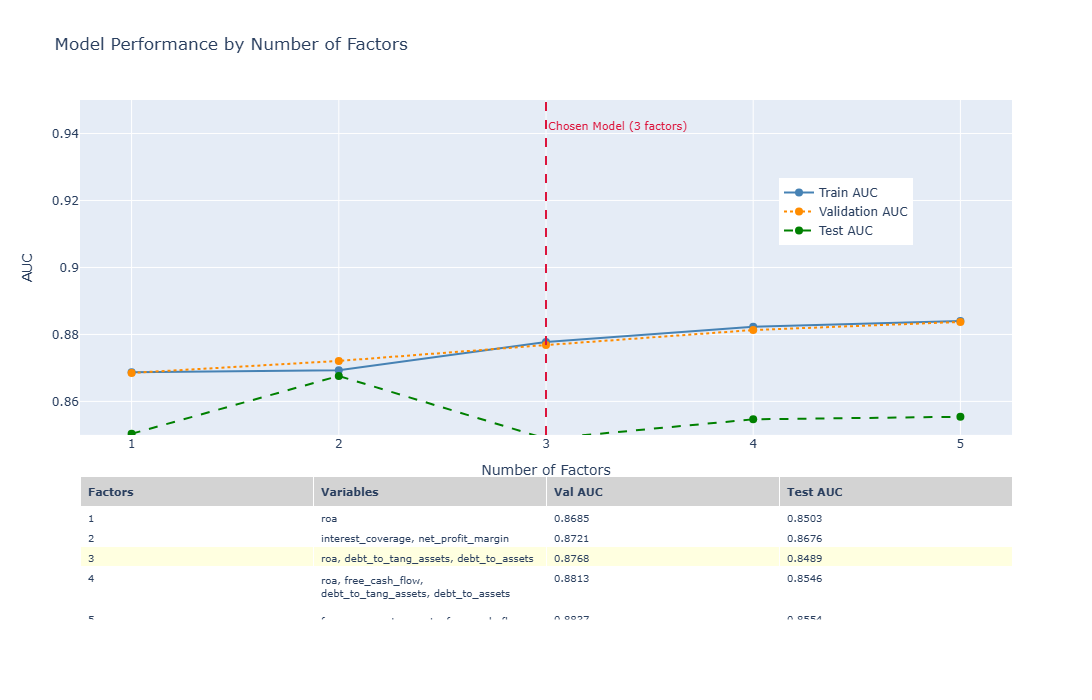

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

n_factors = list(range(1, len(train_aucs) + 1))
chosen = 3  # your chosen model

fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.7, 0.3],
    specs=[[{"type": "scatter"}], [{"type": "table"}]],
    vertical_spacing=0.08
)

# --- AUC lines ---
fig.add_trace(go.Scatter(
    x=n_factors, y=train_aucs,
    mode='lines+markers', name='Train AUC',
    line=dict(color='steelblue', width=2),
    marker=dict(size=8)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=n_factors, y=validation_aucs,
    mode='lines+markers', name='Validation AUC',
    line=dict(color='darkorange', width=2, dash='dot'),
    marker=dict(size=8)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=n_factors, y=test_aucs,
    mode='lines+markers', name='Test AUC',
    line=dict(color='green', width=2, dash='dash'),
    marker=dict(size=8)
), row=1, col=1)

# --- highlight chosen model ---
fig.add_shape(
    type='line',
    x0=chosen, x1=chosen,
    y0=0, y1=1,
    yref='y domain',
    line=dict(color='crimson', width=2, dash='dash'),
    row=1, col=1
)

fig.add_annotation(
    x=chosen, y=0.95,
    yref='y domain',
    text=f'Chosen Model ({chosen} factors)',
    showarrow=False,
    font=dict(color='crimson', size=11),
    xanchor='left',
    row=1, col=1
)

# --- combo table ---
fig.add_trace(go.Table(
    header=dict(
        values=['<b>Factors</b>', '<b>Variables</b>', '<b>Val AUC</b>', '<b>Test AUC</b>'],
        fill_color='lightgrey',
        align='left',
        font=dict(size=11)
    ),
    cells=dict(
        values=[
            n_factors,
            [', '.join(c) for c in best_combos],
            [f'{x:.4f}' for x in validation_aucs],
            [f'{x:.4f}' for x in test_aucs],
        ],
        fill_color=[['white' if n != chosen else 'lightyellow' for n in n_factors]],
        align='left',
        font=dict(size=10)
    )
), row=2, col=1)

fig.update_layout(
    title='Model Performance by Number of Factors',
    xaxis=dict(title='Number of Factors', tickmode='linear', dtick=1),
    yaxis=dict(title='AUC', range=[0.85, 0.95]),
    legend=dict(x=0.75, y=0.85),
    hovermode='x unified',
    width=900, height=700
)

fig.show()